## Data cleaning & Preprocessing
Data cleaning involves identifying and removing any missing, duplicate or irrelevant data.

- Raw data (log file, transactions, audio /video recordings, etc) is often noisy, incomplete and inconsistent which can negatively impact the accuracy of the model.
- The goal of data cleaning is to ensure that the data is accurate, consistent and free of errors.
- Clean datasets are also important in EDA (Exploratory Data Analysis), which enhances the interpretability of data so that the right actions can be taken based on insights.

### How to Perform Data Cleaning
Data cleaning involves identifying issues like missing values, duplicates, and outliers, followed by applying appropriate techniques to fix them. The following steps are essential to perform data cleaning:

- Remove Unwanted Observations: Eliminate duplicates, irrelevant entries or redundant data that add noise.
- Fix Structural Errors: Standardize data formats and variable types for consistency.
- Manage Outliers: Detect and handle extreme values that can skew results, either by removal or transformation.
- Handle Missing Data: Address gaps using imputation, deletion or advanced techniques to maintain accuracy and integrity.

### Implementation for Data Cleaning

#### Import Libraries and Load Dataset

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('Titanic-Dataset (1).csv')

In [2]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


#### EDA (Exploratory Data Analysis)

**Exploratory Data Analysis (EDA)** is an important step in data analysis where we explore and visualise the data to understand its main features, find patterns and see how different variables are related.

Importance
- Provides a clear understanding of the dataset, including the number of features, data types and data distribution.
- Reveals patterns and relationships between different variables in the data.
- Identifies errors and outliers that may affect analysis.
- Highlights the most important features useful for building models.
- Supports selecting suitable modelling techniques for better results.

#### Types of Exploratory Data Analysis

1. Univariate Analysis
2. Bivariate Analysis
3. Multivariate Analysis

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [4]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


### Check for Distribution of numeric values

In [5]:
# Drop PassengerId
# PassengerId is just an identifier, not a feature.
df1 = df.drop(columns=['PassengerId'])

In [6]:
# Select numeric columns
numeric_cols = df1.select_dtypes(include=['int64', 'float64']).columns
print(numeric_cols)

Index(['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare'], dtype='str')


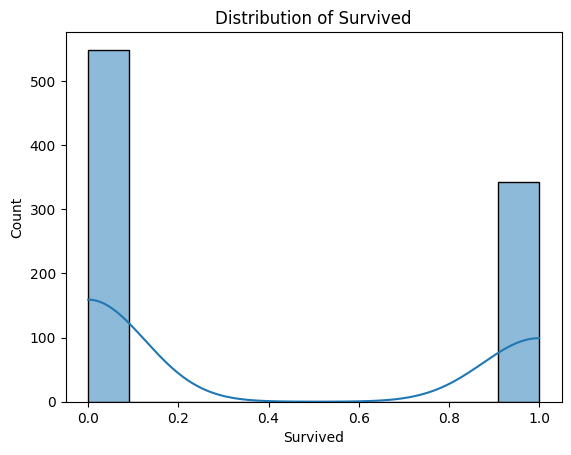

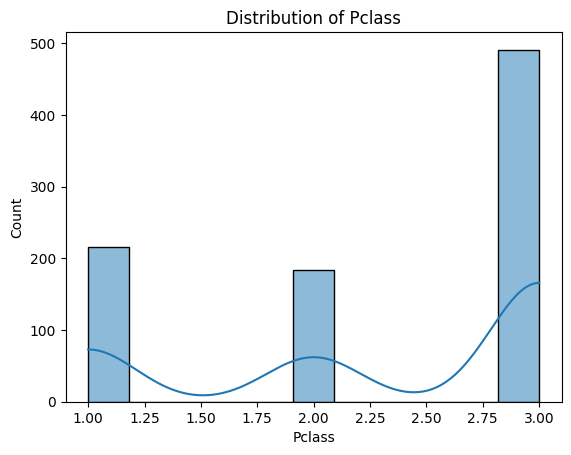

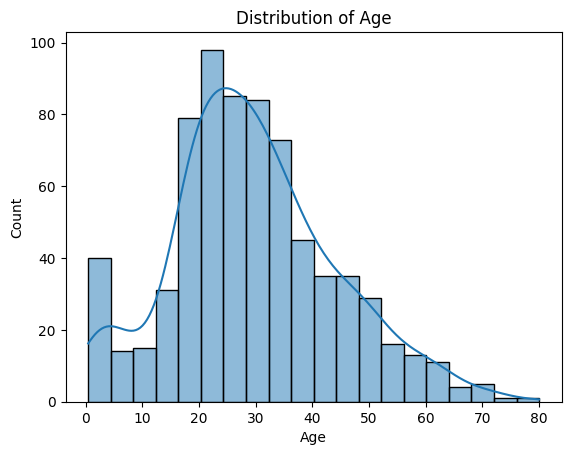

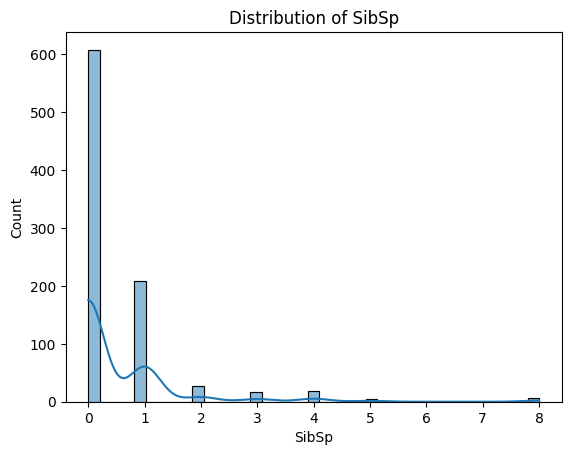

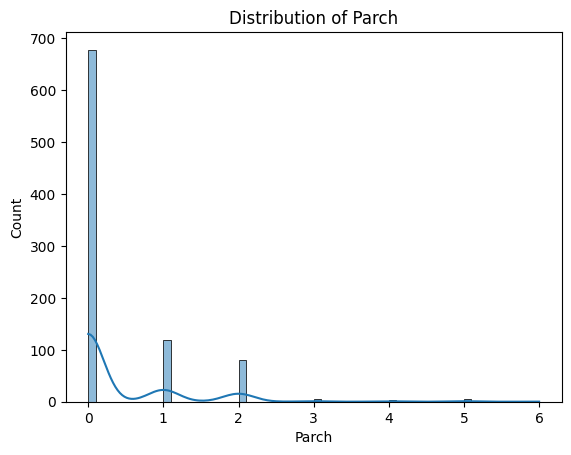

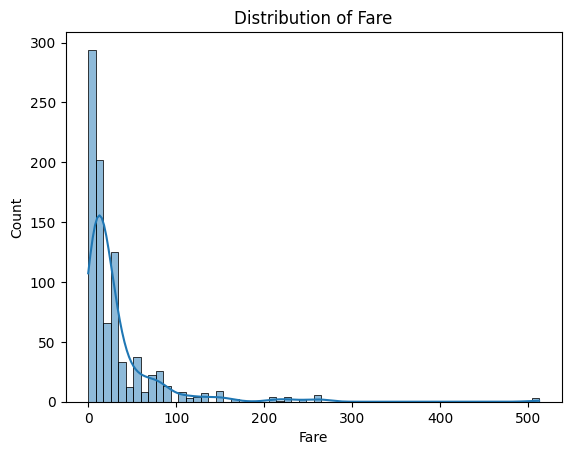

In [7]:
# Plot distributions (before scaling)
# Histograms for all numeric columns
for col in numeric_cols:
    plt.figure()
    sns.histplot(df1[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()

### Target Variable Analysis (Survival)

In [8]:
df1['Survived'].value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

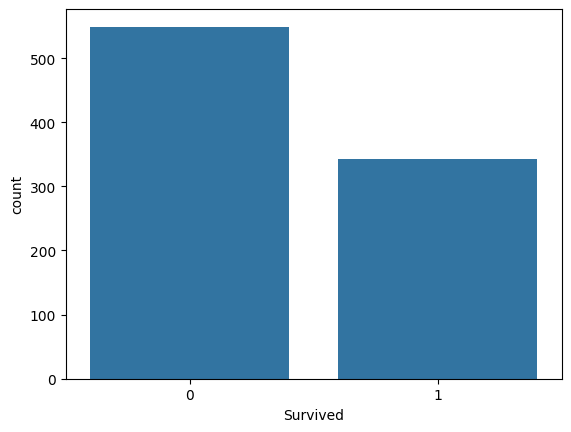

In [9]:
sns.countplot(x='Survived', data=df1)
plt.show()

#### Survival vs Gender

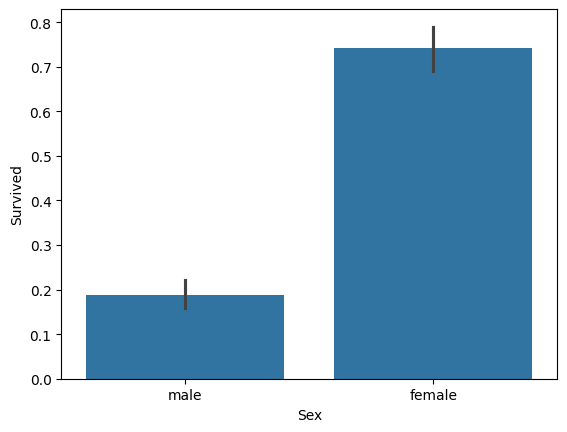

In [10]:
sns.barplot(x='Sex', y='Survived', data=df1)
plt.show()

#### Survival vs Passenger Class

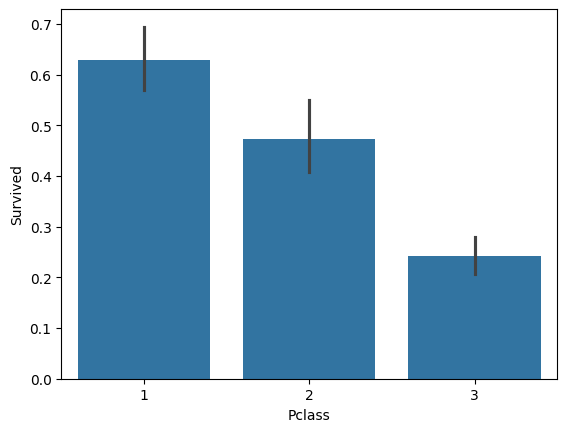

In [11]:
sns.barplot(x='Pclass', y='Survived', data=df1)
plt.show()

#### Age Distribution

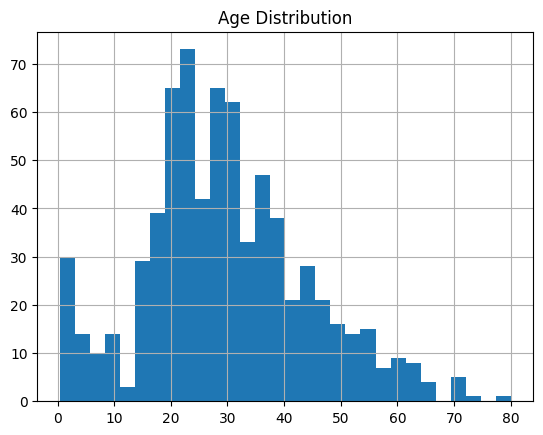

In [12]:
df1['Age'].hist(bins=30)
plt.title("Age Distribution")
plt.show()

#### Age vs Survival

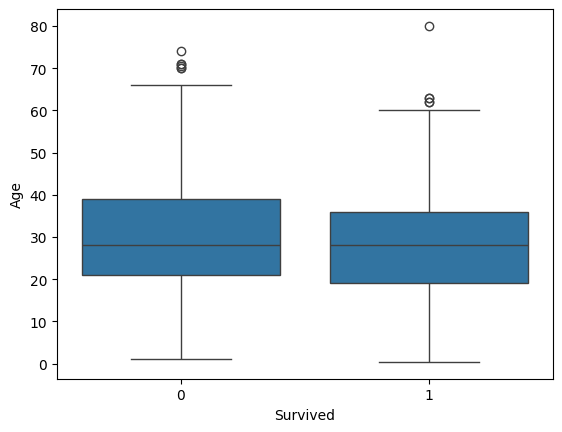

In [39]:
sns.boxplot(x='Survived', y='Age', data=df1)
plt.show()

Younger passengers had slightly higher survival chance

#### Fare Distribution

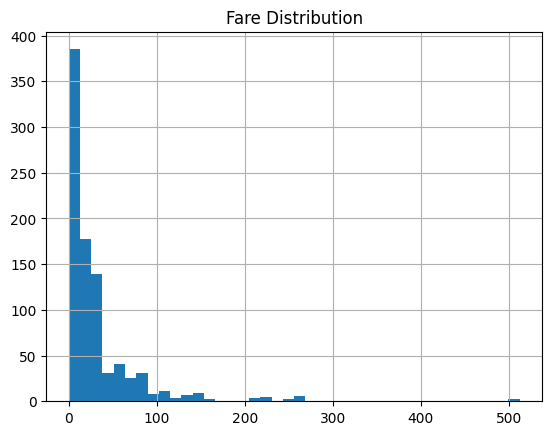

In [13]:
df1['Fare'].hist(bins=40)
plt.title("Fare Distribution")
plt.show()

Highly skewed (few people paid very high fares)

#### Correlation Analysis

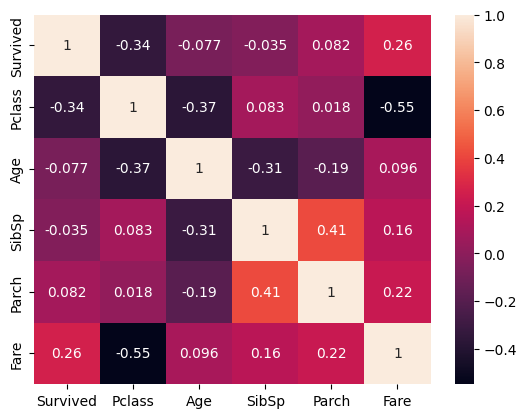

In [14]:
sns.heatmap(df1.corr(numeric_only=True), annot=True)
plt.show()

#### Missing Values Analysis

In [42]:
df1.isnull().sum()

Survived      0
Pclass        0
Name          0
Sex           0
Age         177
SibSp         0
Parch         0
Ticket        0
Fare          0
Cabin       687
Embarked      2
dtype: int64

In [43]:
# convert to percentage
missing_percent = df1.isnull().sum() / len(df1) * 100
print(missing_percent)

Survived     0.000000
Pclass       0.000000
Name         0.000000
Sex          0.000000
Age         19.865320
SibSp        0.000000
Parch        0.000000
Ticket       0.000000
Fare         0.000000
Cabin       77.104377
Embarked     0.224467
dtype: float64


#### Visualize missing data

In [44]:
import missingno as msno

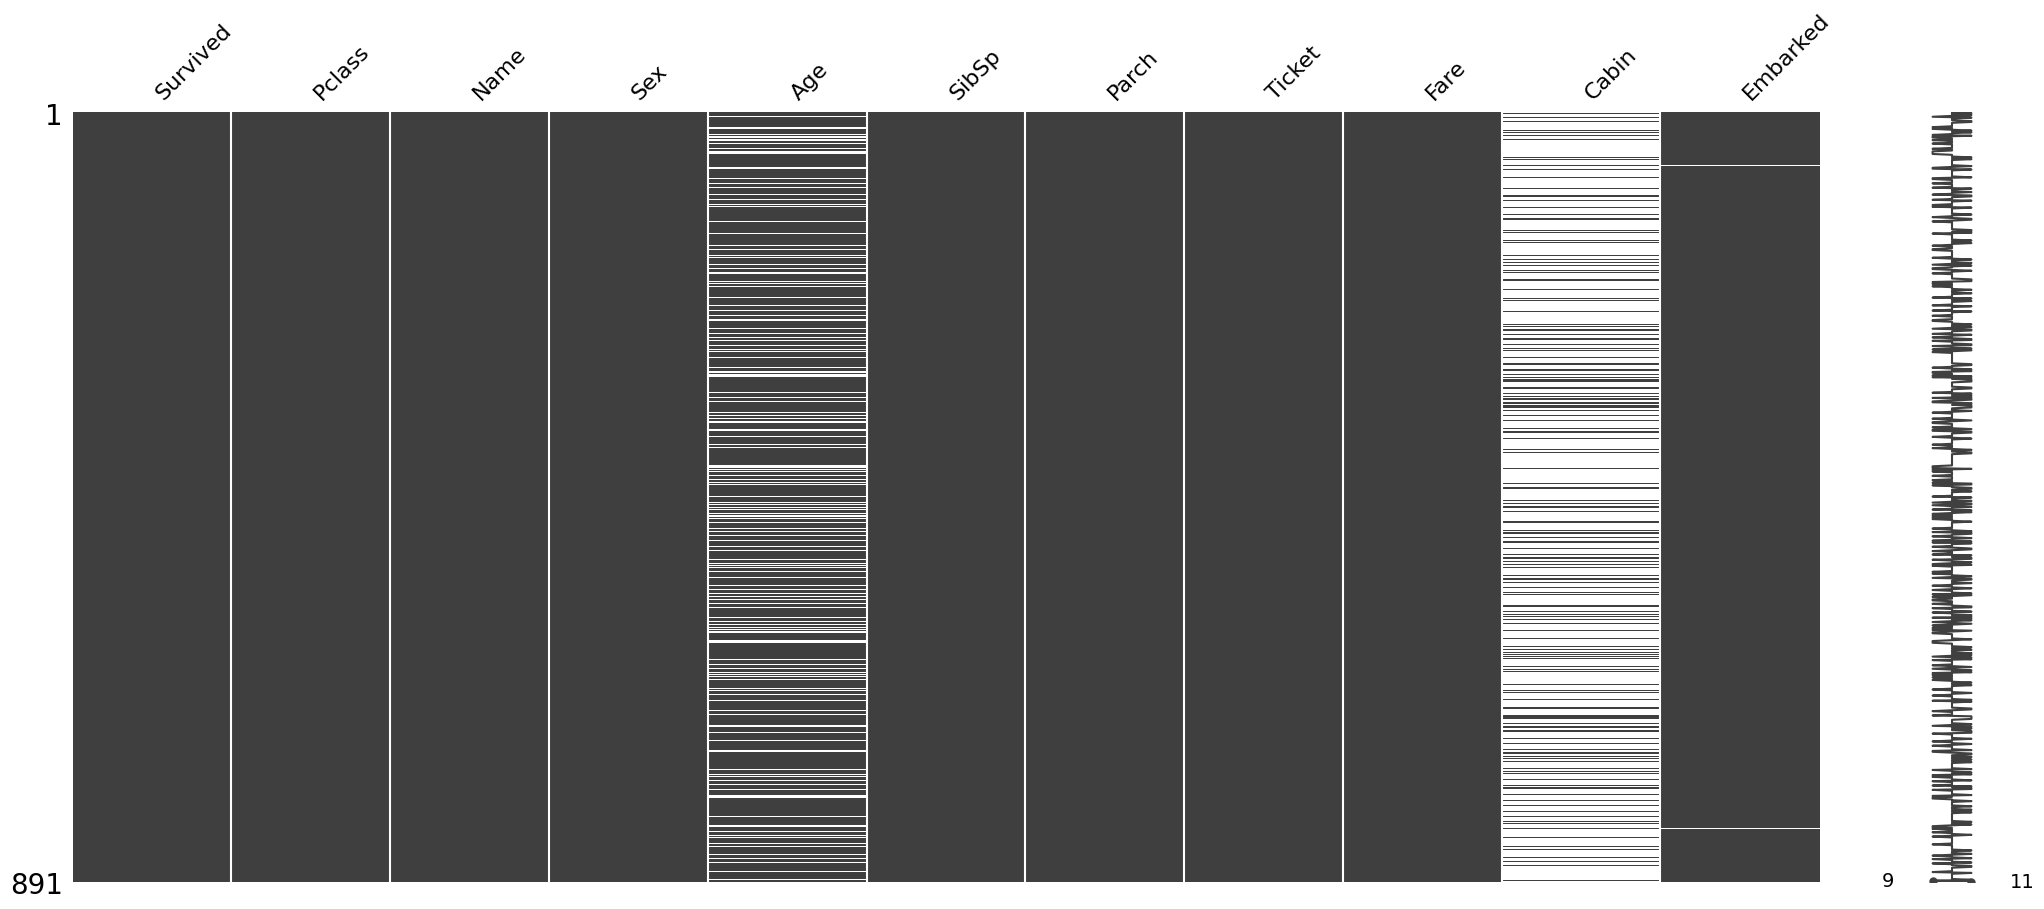

In [45]:
msno.matrix(df1)
plt.show()

#### Interpret the missingness (VERY important in EDA)
- Age (moderate missing)
Likely missing at random
Can be imputed (mean/median)
- Cabin (very high missing)
Too much missing → often dropped
Or engineered into feature (e.g. "has cabin")
- Embarked (very low missing)
Easy fix → mode imputation

#### Drop Irrelevant or Data-Heavy Missing Columns

- `df.drop(columns=[])`: Drops specified columns from the DataFrame.
- `fillna()`: Fills missing values with specified value (e.g., mean).

In [15]:
# preprocessing decisions

# drop irrelevant columns (Name, Ticket)
df2 = df1.drop(columns=['Name', 'Ticket', 'Cabin'])

# Age → mean imputation
df2['Age'] = df2['Age'].fillna(df2['Age'].mean())

# Embarked → mode imputation
df2['Embarked'] = df2['Embarked'].fillna(df2['Embarked'].mode()[0])

#### Detect Outliers with Box Plot

- `matplotlib.pyplot.boxplot()`: Displays distribution of data, highlighting median, quartiles and outliers.
- `plt.show()`: Renders the plot.

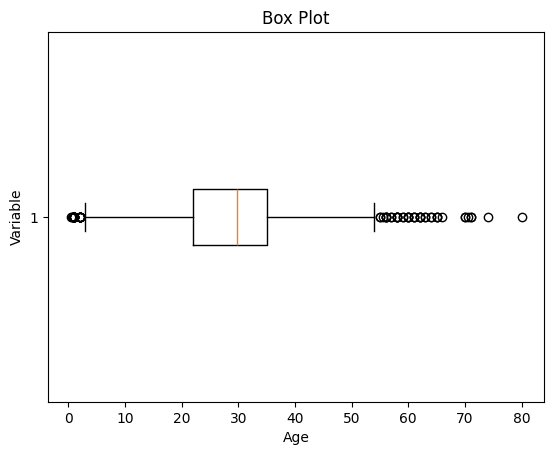

In [16]:
import matplotlib.pyplot as plt

plt.boxplot(df2['Age'], vert=False)
plt.ylabel('Variable')
plt.xlabel('Age')
plt.title('Box Plot')
plt.show()

#### Calculate Outlier Boundaries and Remove Them

In [17]:
# Compute Q1, Q3, IQR
Q1 = df2['Age'].quantile(0.25)
Q3 = df2['Age'].quantile(0.75)
IQR = Q3 - Q1

In [18]:
# Define bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

In [19]:
# Filter the data
df_no_outliers = df2[(df2['Age'] >= lower_bound) & (df2['Age'] <= upper_bound)]

In [20]:
# Check how many you removed
print("Before:", len(df2))
print("After:", len(df_no_outliers))

Before: 891
After: 825


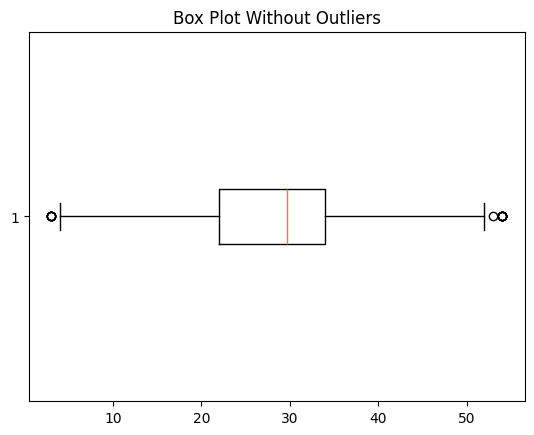

In [21]:
plt.boxplot(df_no_outliers['Age'], vert=False)
plt.title('Box Plot Without Outliers')
plt.show()

In [22]:
df3 = df_no_outliers.fillna(df_no_outliers['Age'].mean())
df3.isnull().sum()

Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64

### Encoding 

#### Identify Column Data Types

In [23]:
cat_col = [col for col in df3.columns if df3[col].dtype == 'str']
num_col = [col for col in df3.columns if df3[col].dtype != 'str']

print('Categorical columns:', cat_col)
print('Numerical columns:', num_col)

Categorical columns: ['Sex', 'Embarked']
Numerical columns: ['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']


#### Count Unique Values in the Categorical Columns

In [24]:
df3[cat_col].nunique()

Sex         2
Embarked    3
dtype: int64

##### Encoding categorical columns: One-Hot Encoding

In [25]:
df4 = pd.get_dummies(df3, columns=['Sex', 'Embarked'], drop_first=True)

In [26]:
df4.head()

,Survived,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S
0,0,3,22.0,1,0,7.2500,True,False,True
1,1,1,38.0,1,0,71.2833,False,False,False
2,1,3,26.0,0,0,7.9250,False,False,True
3,1,1,35.0,1,0,53.1000,False,False,True
4,0,3,35.0,0,0,8.0500,True,False,True


In [27]:
df4.dtypes

Survived        int64
Pclass          int64
Age           float64
SibSp           int64
Parch           int64
Fare          float64
Sex_male         bool
Embarked_Q       bool
Embarked_S       bool
dtype: object

In [28]:
bool_cols = ['Sex_male', 'Embarked_Q', 'Embarked_S']

df4[bool_cols] = df4[bool_cols].astype(int)

In [29]:
df4.dtypes

Survived        int64
Pclass          int64
Age           float64
SibSp           int64
Parch           int64
Fare          float64
Sex_male        int64
Embarked_Q      int64
Embarked_S      int64
dtype: object

### What is Feature Scaling?

Feature scaling puts numerical variables on a similar scale so that no feature dominates others just because of its magnitude.

Example:

- Age: 0–80
- Fare: 0–500+
- SibSp: 0–8

> Without scaling, Fare would dominate models like Logistic Regression or KNN

#### Decide what to scale

##### Do NOT scale:
- Survived (target)
- Sex_male, Embarked_Q, Embarked_S (already 0/1 encoded features)
- Pclass (optional — often left as-is since it’s ordinal)

##### Scale:
- Age - roughly normal with slight skew - StandardScaler
- Fare - Strong right skew with a few extremely large values (outliers)
- SibSp - Discrete count feature, Not normally distributed, StandardScaler (or leave unscaled for tree models)
- Parch - Similar to SibSp, discrete count variable

In [30]:
from sklearn.preprocessing import StandardScaler, RobustScaler

std_scaler = StandardScaler()
rob_scaler = RobustScaler()

df4[['Age', 'SibSp', 'Parch']] = std_scaler.fit_transform(df4[['Age', 'SibSp', 'Parch']])

df4[['Fare']] = rob_scaler.fit_transform(df4[['Fare']].values.reshape(-1, 1))

##### StandardScaler on Age, SibSp, Parch
- Centers data around 0
- Scales by standard deviation
- Good for roughly normal / small-range features

##### RobustScaler on Fare
- Uses median instead of mean
- Uses IQR instead of std
- Handles outliers (very important for Fare)

> `.values.reshape(-1, 1)` is used because:

- RobustScaler expects 2D input

In [31]:
df4[['Age', 'SibSp', 'Parch', 'Fare']].describe()

,Age,SibSp,Parch,Fare
count,8.250000e+02,8.250000e+02,8.250000e+02,825.000000
mean,4.736952e-17,-2.583792e-17,-1.722528e-17,0.814743
std,1.000607e+00,1.000607e+00,1.000607e+00,2.252827
min,-2.543074e+00,-4.659400e-01,-4.480252e-01,-0.605037
25%,-6.760344e-01,-4.659400e-01,-4.480252e-01,-0.248970
50%,8.052132e-02,-4.659400e-01,-4.480252e-01,0.000000
75%,5.031486e-01,4.514836e-01,-4.480252e-01,0.751030
max,2.468454e+00,6.873449e+00,7.069685e+00,22.498873


This causes data leakage:

- The scaler learns from all data (including test data)
- That means your model indirectly “sees” the test set during training
- Results become overly optimistic and unrealistic

#### Correct place to apply scaling

#### After train-test split

#### Define features and target

In [32]:
X = df4.drop(columns=['Survived'])
y = df4['Survived']

#### Train-test split

In [33]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

#### Apply scaling

In [34]:
from sklearn.preprocessing import StandardScaler, RobustScaler

std_scaler = StandardScaler()
rob_scaler = RobustScaler()

cols_std = ['Age', 'SibSp', 'Parch']
cols_rob = ['Fare']

# Fit on training data
X_train[cols_std] = std_scaler.fit_transform(X_train[cols_std])
X_train[cols_rob] = rob_scaler.fit_transform(X_train[cols_rob])

# Transform test data
X_test[cols_std] = std_scaler.transform(X_test[cols_std])
X_test[cols_rob] = rob_scaler.transform(X_test[cols_rob])

#### Train Logistic Regression Model

In [35]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

#### Make Predictions

In [36]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

###### How it works internally:
1. Model computes probability using logistic function
2. Applies a threshold (default = 0.5)
3. Converts to class:
- If probability ≥ 0.5 → 1
- If probability < 0.5 → 0

#### Basic Evaluation

In [37]:
from sklearn.metrics import accuracy_score

accuracy_score(y_test, y_pred)

0.8242424242424242

#### Full Evaluation Metrics

In [38]:
from sklearn.metrics import confusion_matrix

confusion_matrix(y_test, y_pred)

array([[85, 14],
       [15, 51]])

- True Negatives (TN = 85)
Correctly predicted passengers who did not survive
- False Positives (FP = 14)
Predicted survived, but actually did not survive
- False Negatives (FN = 15)
Predicted did not survive, but actually survived
- True Positives (TP = 51)
Correctly predicted passengers who survived

#### Precision / Recall / F1

In [39]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.85      0.86      0.85        99
           1       0.78      0.77      0.78        66

    accuracy                           0.82       165
   macro avg       0.82      0.82      0.82       165
weighted avg       0.82      0.82      0.82       165



- Precision → Of all predicted instances of a class, how many were correct
- Recall → Of all actual instances of a class, how many were correctly identified
- F1-score → Balance between precision and recall
- Support → Number of actual samples in that class

##### Class-wise Interpretation
Class 0 (Did NOT Survive)

- Precision: 0.85 → 85% of predicted non-survivors were correct
- Recall: 0.86 → 86% of actual non-survivors were correctly identified
- F1-score: 0.85 → Strong balance between precision and recall
- Support: 99 → There are 99 non-survivors

> The model performs very well on this class

Class 1 (Survived)

- Precision: 0.78 → 78% of predicted survivors were correct
- Recall: 0.77 → 77% of actual survivors were correctly identified
- F1-score: 0.78 → Slightly lower than class 0
- Support: 66 → There are 66 survivors

> The model performs moderately well, but worse than class 0

#### ROC-AUC

In [40]:
from sklearn.metrics import roc_auc_score

roc_auc_score(y_test, y_prob)

0.8827670645852463

### Error Analysis
#### Build results table

In [41]:
import pandas as pd

results = X_test.copy()
results['Actual'] = y_test.values
results['Predicted'] = y_pred
results['Probability'] = y_prob

#### Extract mistakes

In [42]:
errors = results[results['Actual'] != results['Predicted']]
errors.head()

,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S,Actual,Predicted,Probability
444,3,0.097456,-0.448849,-0.448850,-0.230225,1,0,1,1,0,0.093846
724,1,-0.166812,0.438098,-0.448850,1.888908,1,0,1,1,0,0.444059
233,3,-2.320809,3.098936,2.072351,0.866142,0,0,1,1,0,0.498704
852,3,-1.929174,0.438098,0.811750,0.105788,0,0,0,0,1,0.729985
766,1,0.097456,-0.448849,-0.448850,1.252991,1,0,0,0,1,0.558006


### Pattern analysis
#### Where are errors happening?

In [43]:
errors['Pclass'].value_counts()

Pclass
3    19
1     8
2     2
Name: count, dtype: int64

#### Gender-related errors

In [45]:
errors['Sex_male'].value_counts()

Sex_male
1    16
0    13
Name: count, dtype: int64

#### Confidence analysis

- High probability but wrong → model overconfident
- Low probability mistakes → uncertainty area

In [46]:
errors[['Actual', 'Predicted', 'Probability']].head()

,Actual,Predicted,Probability
444,1,0,0.093846
724,1,0,0.444059
233,1,0,0.498704
852,0,1,0.729985
766,0,1,0.558006


#### Threshold tuning

Default threshold = 0.5

In [47]:
y_pred_new = (y_prob > 0.4).astype(int)

In [ ]:
confusion_matrix(y_test, y_pred_new)

array([[76, 23],
       [11, 55]])